# Imports

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report,
    ConfusionMatrixDisplay
)

# Task 1 — Data Loading & Exploration

In [2]:
# Load data and display first 10 rows.
# Please ensure the dataset is loaded into under the files section before running.
# Change the dataset name accordingly if using a different dataset.
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


In [3]:
# Check the number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1470
Number of columns: 35


In [8]:
# Identification of target col and calculating attrition rate
attrition_rate = (df["Attrition"].value_counts()["Yes"] / len(df)) * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [11]:
# Count employees who left vs stayed
attrition_counts = df["Attrition"].value_counts()

print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [12]:
# Identifying Categorical and Numeric Columns
cat_cols = df.select_dtypes(include=["object"]).columns
num_cols = df.select_dtypes(include=["float64", "int64"]).columns

print(f"Categorical Columns: {list(cat_cols)}")
print(f"Number of Categorical Columns: {len(cat_cols)}")
print(f"Numerical Columns: {list(num_cols)}")
print(f"Number of Numerical Columns: {len(num_cols)}")

Categorical Columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
Number of Categorical Columns: 9
Numerical Columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Number of Numerical Columns: 26


***Observation:*** The dataset is ***imbalanced***, as only ***16.12%*** of employees have left the company while ***83.88%*** stayed. This means the majority class ("No") significantly outweighs the minority class ("Yes"), which should be considered during model training and evaluation.

# Task 2 — Data Cleaning & Preprocessing

In [15]:
# Checking for missing or null values..
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [17]:
print(f"Number of missing values: {df.isna().sum().sum()}")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of missing values: 0
Number of duplicate rows: 0


No missing values and duplicate rows found. If using a different dataset please uncomment the following blocks according to your preference before running.

In [ ]:
# ==========================================
# HANDLING MISSING VALUES (Optional Safeguard)
# ==========================================
# Note: The current dataset contains no missing values, but if a different
# dataset is used in the future, choose ONE of the options below:

# OPTION 1: Drop rows with any missing values
# df = df.dropna()

# OPTION 2 : Fill missing values with one of the options below according to your preference

In [ ]:
# ==========================================
# HANDLING MISSING VALUES (Using Pandas fillna)
# ==========================================
# Note: Current dataset has 545 records and 13 attributes with no missing values[cite: 5].
# If a new dataset is used, uncomment below:

# 1. Fill missing numerical values with the Mean
# num_cols = df.select_dtypes(include=['int64', 'float64']).columns
# df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# 2. Fill missing categorical values with the Most Frequent value (Mode)
# cat_cols = df.select_dtypes(include=['object', 'category']).columns
# for col in cat_cols:
#     df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# ==========================================
# HANDLING MISSING VALUES (Using SimpleImputer)
# ==========================================
# from sklearn.impute import SimpleImputer

# # Split features before encoding
# num_cols = df.select_dtypes(include=['int64', 'float64']).columns
# cat_cols = df.select_dtypes(include=['object', 'category']).columns

# # Impute numerical with mean, categorical with most frequent
# num_imputer = SimpleImputer(strategy='mean')
# cat_imputer = SimpleImputer(strategy='most_frequent')

# df[num_cols] = num_imputer.fit_transform(df[num_cols])
# df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [18]:
# Find columns with only one unique value
constant_cols = [col for col in df.columns if df[col].nunique() == 1]

print("Constant Columns:", constant_cols)

Constant Columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [19]:
# Dropping cols that add no value to the prediction
cols_to_drop = constant_cols + ["EmployeeNumber"]

df.drop(columns=cols_to_drop, inplace=True)

print("Dropped Columns:", cols_to_drop)
print("New Shape:", df.shape)

Dropped Columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
New Shape: (1470, 31)


In [20]:
# Converting attrition to 1/0 from yes/no
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

In [22]:
x = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [27]:
# One Hot Encoding and Standard Scaling
cat_cols = x.select_dtypes(include="object").columns
num_cols = x.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

x_processed = preprocessor.fit_transform(x)

In [34]:
# Summary after preprocessing

print("=" * 50)
print("DATA PREPROCESSING SUMMARY")
print("=" * 50)

print(f"Original Dataset Shape      : {df.shape}")
print(f"Numeric Features           : {len(num_cols)}")
print(f"Categorical Features       : {len(cat_cols)}")

print("\nCategorical Columns:")
print(list(cat_cols))

print("\nNumerical Columns:")
print(list(num_cols))

# Convert processed data to DataFrame
feature_names = preprocessor.get_feature_names_out()
x_processed_df = pd.DataFrame(x_processed, columns=feature_names)

print("\n" + "=" * 50)
print("AFTER ENCODING & SCALING")
print("=" * 50)

print(f"Processed Dataset Shape    : {x_processed_df.shape}")
print(f"Total Features Generated   : {x_processed_df.shape[1]}")

print("\nFirst 10 Processed Features:")
print(feature_names[:10])

print("\n...")
print(f"Total Processed Features: {len(feature_names)}")

DATA PREPROCESSING SUMMARY
Original Dataset Shape      : (1470, 31)
Numeric Features           : 23
Categorical Features       : 7

Categorical Columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

AFTER ENCODING & SCALING
Processed Dataset Shape    : (1470, 44)
Total Features Generated   : 44

First 10 Processed Features:
['num__Age' 'num__DailyRate' 'num__DistanceFromHome' 'num__Education'
 'num__EnvironmentSatisfaction' 'num__HourlyRate' 'num__JobInvolvement'
 'num__JobLe

***NOTE:*** The increase in the number of features is expected because One-Hot Encoding converts each categorical variable into multiple binary indicator columns.

# Task 3 — Exploratory Data Analysis — EDA

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


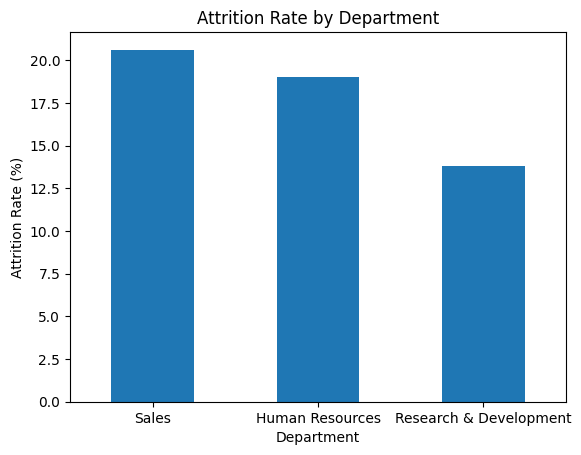

In [35]:
# 1. Attrition Rate by Department
dept_attrition = (
    df.groupby("Department")["Attrition"]
      .mean()
      .sort_values(ascending=False) * 100
)

print(dept_attrition.round(2))

dept_attrition.plot(kind="bar")
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
plt.xticks(rotation=0)
plt.show()

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


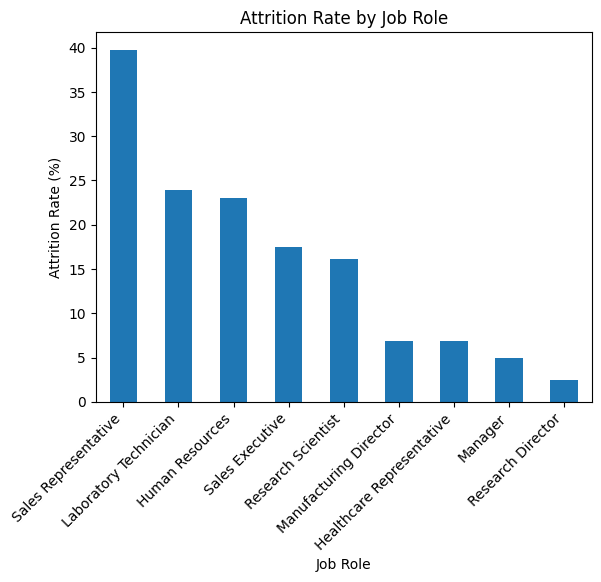

In [36]:
# 2. Attrition Rate by Job Role
job_attrition = (
    df.groupby("JobRole")["Attrition"]
      .mean()
      .sort_values(ascending=False) * 100
)

print(job_attrition.round(2))

job_attrition.plot(kind="bar")
plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Role")
plt.xticks(rotation=45, ha="right")
plt.show()

            count      mean       std     min     25%     50%     75%      max
Attrition                                                                     
0          1233.0  6832.740  4818.208  1051.0  3211.0  5204.0  8834.0  19999.0
1           237.0  4787.093  3640.210  1009.0  2373.0  3202.0  5916.0  19859.0


<Figure size 600x500 with 0 Axes>

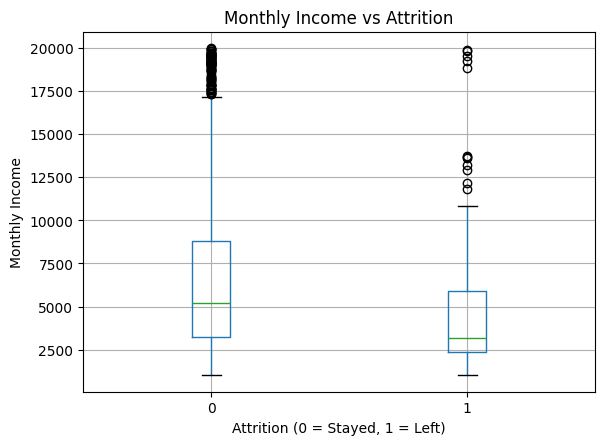

In [71]:
# 3. Attrition vs Monthly Income
print(df.groupby("Attrition")["MonthlyIncome"].describe().round(3))

plt.figure(figsize=(6,5))

df.boxplot(column="MonthlyIncome", by="Attrition")

plt.title("Monthly Income vs Attrition")
plt.suptitle("")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")

plt.show()

WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


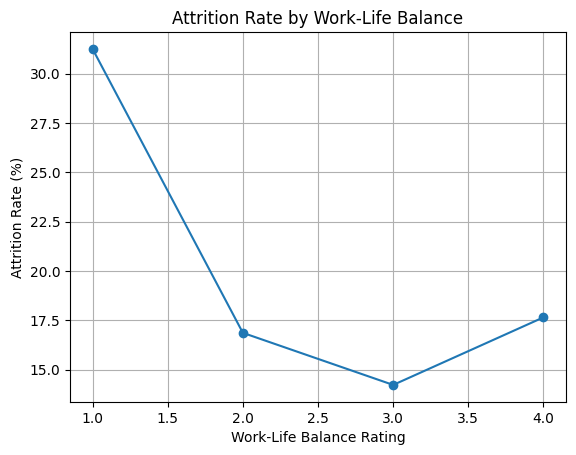

In [38]:
# 4. Attrition vs Work-Life Balance
wlb_attrition = (
    df.groupby("WorkLifeBalance")["Attrition"]
      .mean() * 100
)

print(wlb_attrition.round(2))

wlb_attrition.plot(marker="o")

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")
plt.grid(True)

plt.show()

In [43]:
# Attrition by Years at Company
tenure_summary = (
    df.groupby("YearsAtCompany")
      .agg(
          Employees=("Attrition", "count"),
          AttritionRate=("Attrition", "mean")
      )
      .reset_index()
)

tenure_summary["AttritionRate"] *= 100
tenure_summary["AttritionRate"] = tenure_summary["AttritionRate"].round(2)

print(tenure_summary)

    YearsAtCompany  Employees  AttritionRate
0                0         44          36.36
1                1        171          34.50
2                2        127          21.26
3                3        128          15.62
4                4        110          17.27
5                5        196          10.71
6                6         76          11.84
7                7         90          12.22
8                8         80          11.25
9                9         82           9.76
10              10        120          15.00
11              11         32           6.25
12              12         14           0.00
13              13         24           8.33
14              14         18          11.11
15              15         20           5.00
16              16         12           8.33
17              17          9          11.11
18              18         13           7.69
19              19         11           9.09
20              20         27           3.70
21        

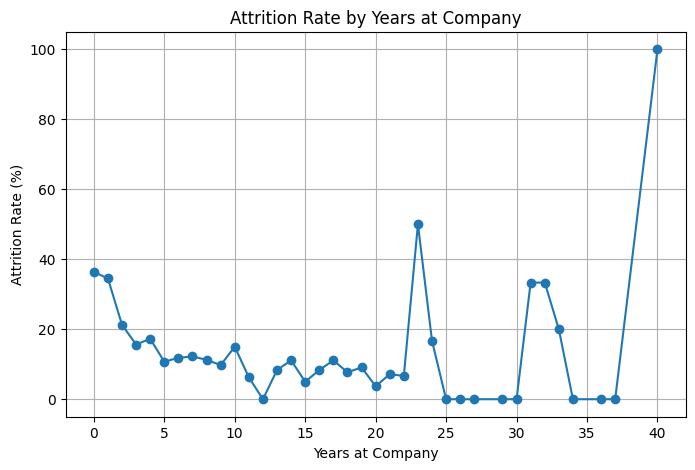

In [44]:
# 5. Attrition vs Years at Company
tenure_attrition = (
    df.groupby("YearsAtCompany")["Attrition"]
      .mean() * 100
)

plt.figure(figsize=(8,5))

tenure_attrition.plot(marker="o")

plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.grid(True)

plt.show()

## Business Insights

1. **Department-wise Attrition:** The **Sales** department has the highest attrition rate (**20.63%**), followed by **Human Resources (19.05%)**, while **Research & Development** has the lowest attrition (**13.84%**). This suggests that customer-facing and HR departments experience greater employee turnover.

2. **Job Role-wise Attrition:** **Sales Representatives** have the highest attrition rate (**39.76%**), more than twice the company's overall attrition rate (**16.12%**). **Laboratory Technicians (23.94%)** and **Human Resources employees (23.08%)** also experience relatively high turnover, whereas **Research Directors (2.50%)** and **Managers (4.90%)** have the lowest attrition.

3. **Monthly Income:** Employees who left the company earned significantly lower salaries on average. The average monthly income of employees who stayed is approximately **6,833**, compared to **4,787** for employees who left, indicating that compensation may influence employee retention.

4. **Work-Life Balance:** Employees with the lowest Work-Life Balance rating (**1**) have an attrition rate of **31.25%**, compared to approximately **14–18%** for employees with ratings **2–4**. This suggests that poor work-life balance is associated with higher employee turnover.

5. **Years at Company:** Attrition is highest during the **first two years of employment**, with rates of **36.36%** for employees in their first year and **34.50%** after one year. Attrition gradually decreases with increasing tenure and generally remains below **12%** after five years, highlighting the importance of retaining employees during their early years with the organization.

## EDA Observations & Limitations

- The analysis identifies **associations** between employee characteristics and attrition but does **not establish causal relationships**. Additional analysis or predictive modeling is required to determine the most influential factors.

- Attrition rates for employees with very long tenures (e.g., **23, 31, 32, and 40 years**) are based on **very small sample sizes** and should not be interpreted as reliable trends.

- Although employees who left the company earned **lower average monthly incomes**, salary alone does not explain attrition. Other factors such as job satisfaction, overtime, career growth, and work-life balance may also contribute.

- Department and job role comparisons are based on **attrition rates**, which normalize for different workforce sizes. However, the absolute number of employees leaving may differ across departments and roles.

- Overall, the EDA indicates that **department, job role, compensation, work-life balance, and employee tenure** are important factors associated with employee attrition and should be considered during predictive model development.

# Task 4 — Model Building & Comparison

In [45]:
# Splitting into train n test sets
xtrain, xtest, ytrain, ytest = train_test_split(
    x_processed_df,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", xtrain.shape)
print("Testing Set :", xtest.shape)

Training Set: (1176, 44)
Testing Set : (294, 44)


In [47]:
# Define Models
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

In [49]:
# Train models
trained_models = {}

for name, model in models.items():
    model.fit(xtrain, ytrain)
    trained_models[name] = model

print("All models trained successfully.")

All models trained successfully.


In [50]:
# Comparison table
comparison_df = pd.DataFrame({
    "Model": list(models.keys()),
    "Class Weight Used": [
        "Balanced",
        "Balanced",
        "Not Supported"
    ],
    "Status": [
        "Trained",
        "Trained",
        "Trained"
    ]
})

comparison_df

,Model,Class Weight Used,Status
0,Logistic Regression,Balanced,Trained
1,Random Forest,Balanced,Trained
2,Gradient Boosting,Not Supported,Trained


All three models were successfully trained on the preprocessed training data and are evaluated in the next section using multiple performance metrics.

# Task 5 — Model Evaluation

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



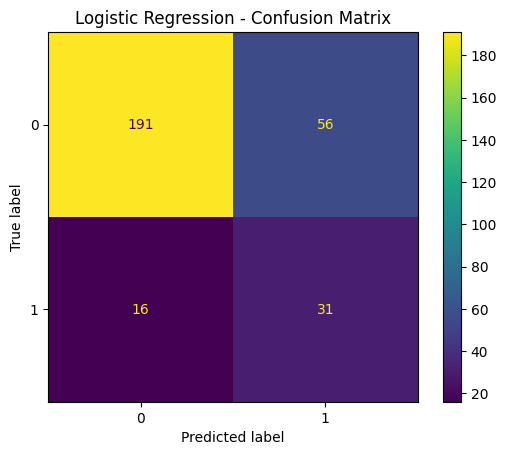

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294



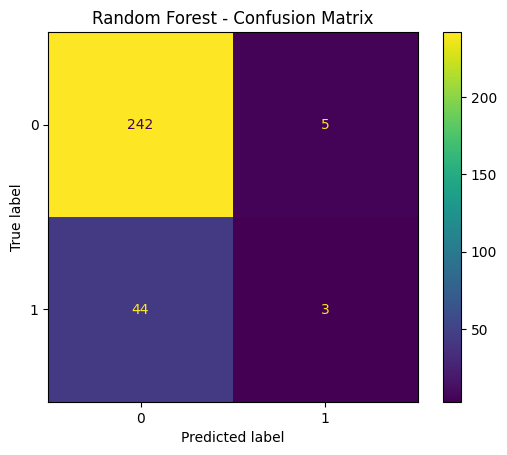

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



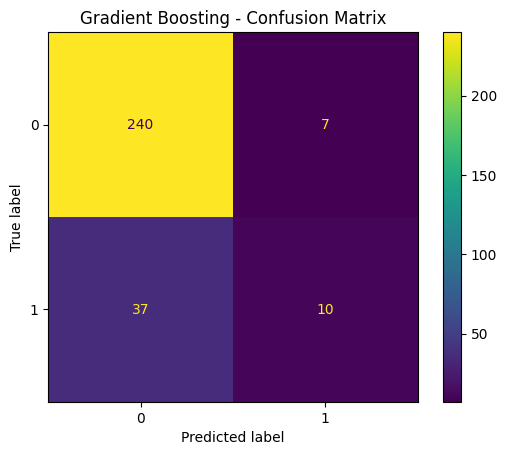

In [52]:
# Evaluate all models
results = []

for name, model in trained_models.items():

    # Predictions
    y_pred = model.predict(xtest)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(xtest)[:, 1]

    # Metrics
    precision = precision_score(ytest, y_pred)
    recall = recall_score(ytest, y_pred)
    f1 = f1_score(ytest, y_pred)
    roc_auc = roc_auc_score(ytest, y_prob)

    # Store results
    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    # Print detailed results
    print("=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(ytest, y_pred))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(ytest, y_pred)

    plt.title(f"{name} - Confusion Matrix")
    plt.show()

In [61]:
# Comparison Table
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

comparison_df = comparison_df.round(3)

comparison_df

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.356,0.660,0.463,0.804
1,Gradient Boosting,0.588,0.213,0.312,0.794
2,Random Forest,0.375,0.064,0.109,0.752


In [54]:
# Best model
best_model_name = comparison_df.iloc[0]["Model"]

print(f"Best Model: {best_model_name}")

Best Model: Logistic Regression


In [59]:
best_model = trained_models[best_model_name]

if hasattr(best_model, "feature_importances_"):
    importance = best_model.feature_importances_

elif hasattr(best_model, "coef_"):
    importance = abs(best_model.coef_[0])

feature_importance = pd.DataFrame({
    "Feature": x_processed_df.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)
feature_importance.head(10)

,Feature,Importance
43,cat__OverTime_Yes,1.626169
23,cat__BusinessTravel_Travel_Frequently,1.596964
34,cat__JobRole_Laboratory Technician,1.571637
40,cat__JobRole_Sales Representative,1.264294
37,cat__JobRole_Research Director,1.112054
30,cat__EducationField_Other,1.020279
24,cat__BusinessTravel_Travel_Rarely,0.903722
42,cat__MaritalStatus_Single,0.864502
33,cat__JobRole_Human Resources,0.670991
16,num__TotalWorkingYears,0.612480


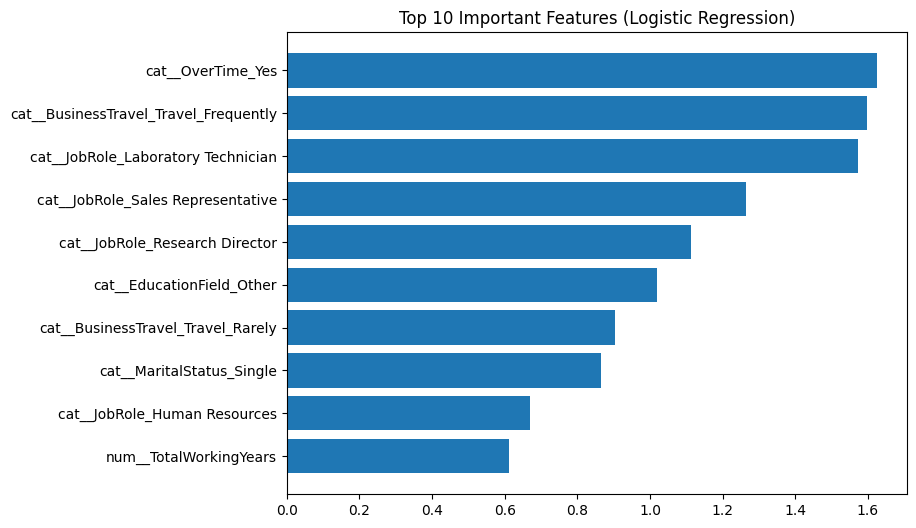

In [60]:
# Plot top 10 features
top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.title(f"Top 10 Important Features ({best_model_name})")

plt.gca().invert_yaxis()

plt.show()

## Model Evaluation

The three machine learning models were evaluated using **Precision, Recall, F1-Score, ROC-AUC Score,** and **Confusion Matrices**.

### Model Comparison

| Model | Precision | Recall | F1-Score | ROC-AUC |
|-------|----------:|-------:|---------:|--------:|
| Logistic Regression | 0.356 | 0.660 | 0.463 | 0.804 |
| Gradient Boosting | 0.588 | 0.213 | 0.313 | 0.794 |
| Random Forest | 0.375 | 0.064 | 0.109 | 0.752 |

### Best Performing Model

Although **Gradient Boosting** achieved the highest precision and overall accuracy, **Logistic Regression** produced the **highest Recall (0.660)**, **highest F1-Score (0.463)**, and **highest ROC-AUC score (0.804)**.

For employee attrition prediction, **Recall is the most important metric** because the goal is to identify employees who are at risk of leaving so that HR can take preventive action.

- **Logistic Regression** correctly identifies approximately **66%** of employees who are likely to leave.
- **Gradient Boosting** identifies only about **21%** of employees who leave.
- **Random Forest** identifies only about **6%** of employees who leave.

Although Logistic Regression has a lower overall accuracy (**76%**) than Gradient Boosting (**85%**), it is **far more effective at detecting employees who may resign**. A few additional false alarms are generally preferable to missing employees who are genuinely at risk of leaving.

Therefore, **Logistic Regression was selected as the best-performing model** because it provides the best balance between predictive performance, interpretability, and practical usefulness for HR decision-making.

# Task 6 — Visualization (Minimum 4 charts)

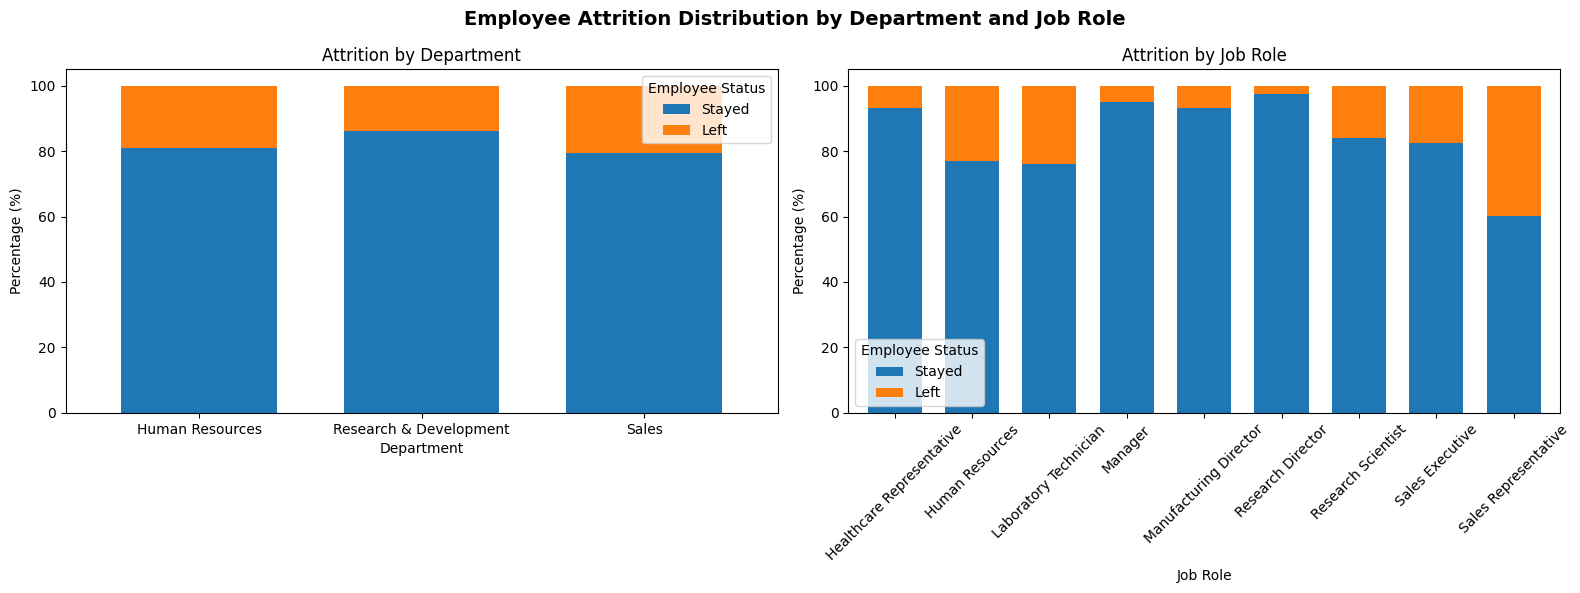

In [70]:
# Chart 1 — Attrition by Department and Job Role
# Department and Job Role Attrition (100% Stacked Bar Charts)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -----------------------------
# Department
# -----------------------------
dept_prop = (
    df.groupby(["Department", "Attrition"])
      .size()
      .unstack(fill_value=0)
)

dept_prop = dept_prop.div(dept_prop.sum(axis=1), axis=0) * 100

dept_prop.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    width=0.7
)

axes[0].set_title("Attrition by Department")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Percentage (%)")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(["Stayed", "Left"], title="Employee Status")


# -----------------------------
# Job Role
# -----------------------------
role_prop = (
    df.groupby(["JobRole", "Attrition"])
      .size()
      .unstack(fill_value=0)
)

role_prop = role_prop.div(role_prop.sum(axis=1), axis=0) * 100

role_prop.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    width=0.7
)

axes[1].set_title("Attrition by Job Role")
axes[1].set_xlabel("Job Role")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(["Stayed", "Left"], title="Employee Status")

plt.suptitle(
    "Employee Attrition Distribution by Department and Job Role",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

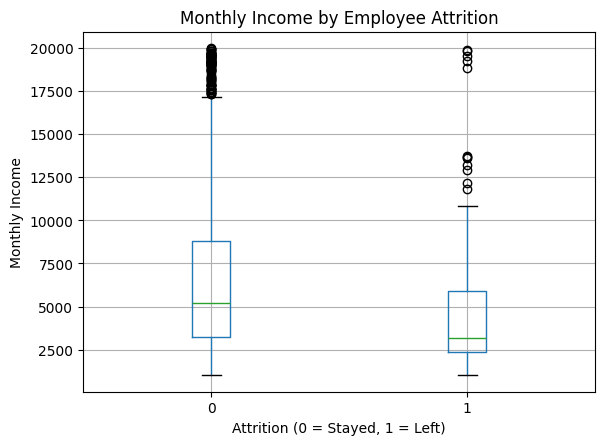

In [65]:
# Chart 2 — Monthly Income Boxplot
plt.figure(figsize=(6,5))

df.boxplot(column="MonthlyIncome", by="Attrition")

plt.title("Monthly Income by Employee Attrition")
plt.suptitle("")

plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")

plt.show()

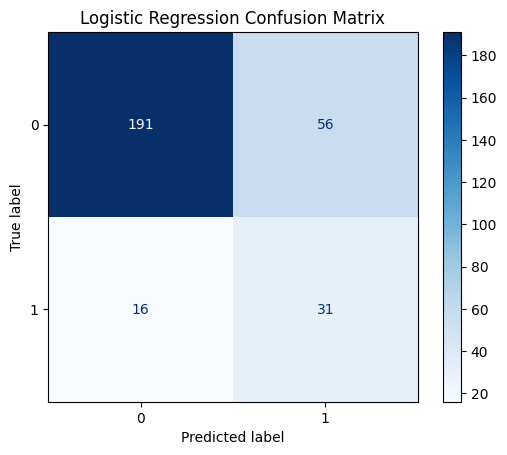

In [66]:
# Chart 3 — Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    trained_models[best_model_name],
    xtest,
    ytest,
    cmap="Blues"
)

plt.title(f"{best_model_name} Confusion Matrix")

plt.show()

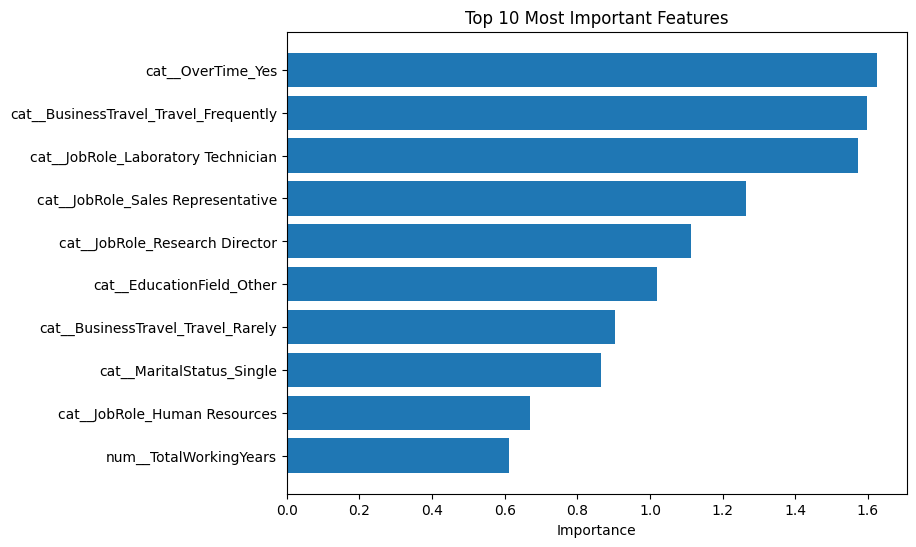

In [67]:
# Chart 4 — Top 10 Features
top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Most Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

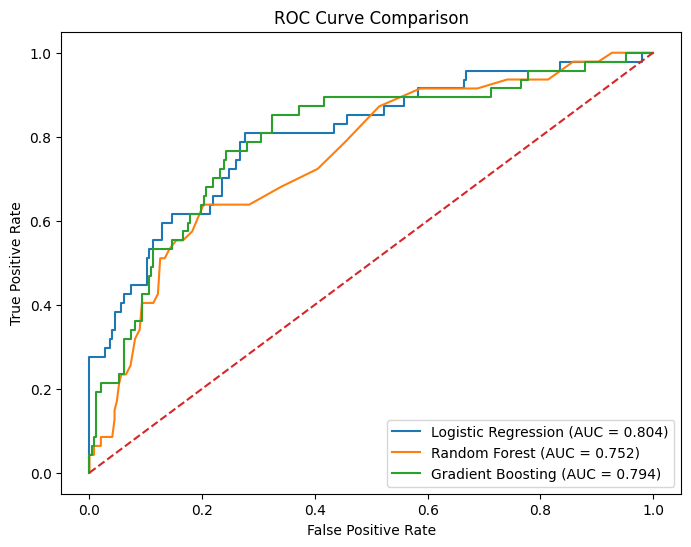

In [69]:
# Chart 5 (Bonus) — ROC Curves
plt.figure(figsize=(8,6))

for name, model in trained_models.items():

    probs = model.predict_proba(xtest)[:,1]

    fpr, tpr, _ = roc_curve(ytest, probs)

    auc = roc_auc_score(ytest, probs)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

## Key Takeaways from the Visualizations

The visualizations reinforce the findings from the exploratory analysis and model evaluation.

- Sales and customer-facing roles exhibit the highest employee attrition.
- Employees who leave generally earn lower monthly incomes.
- The confusion matrix shows that Logistic Regression successfully identifies a larger proportion of employees likely to leave compared with the other models.
- Feature importance highlights the variables that contribute most to predicting employee attrition, providing valuable insights for HR decision-making.
- The ROC Curve comparison confirms that Logistic Regression achieves the best overall discriminative performance among the evaluated models.

# Task 7 — HR Insights & Business Recommendations


## HR Insights & Business Recommendations

### Key Findings

The analysis shows that employee attrition is influenced more by **work conditions and job characteristics** than by salary alone. Although employees who left earned **lower monthly incomes on average** than those who stayed, the predictive model found that **Monthly Income was not among the strongest predictors of attrition**. Instead, the three strongest indicators were **working overtime**, **frequent business travel**, and **specific job roles**, particularly **Laboratory Technicians** and **Sales Representatives**. The exploratory analysis also showed that the **Sales department** had the highest attrition rate (**20.63%**), while employees with **0–2 years of tenure** were considerably more likely to leave than longer-serving employees. These findings suggest that improving working conditions and supporting high-risk employee groups may have a greater impact on retention than salary increases alone.

### HR Recommendations

1. **Prioritize employees who work overtime or travel frequently.** HR should regularly monitor employees with heavy workloads or frequent travel schedules and conduct proactive retention conversations before signs of burnout develop. Flexible scheduling, workload balancing, and wellness initiatives may help reduce voluntary attrition.

2. **Focus retention efforts on high-risk job roles and early-career employees.** Sales Representatives, Laboratory Technicians, and Human Resources employees, particularly those within their first two years at the company, should receive targeted mentoring, career development opportunities, and regular check-ins to improve engagement and long-term retention.

### Model Limitation

This model should be used as a **decision-support tool** rather than an automated decision-maker. It identifies employees who may be at higher risk of leaving based on historical patterns but cannot determine the exact reason why an individual employee may resign. Personal circumstances, organizational changes, future economic conditions, and other factors not included in the dataset may also influence employee attrition. Therefore, model predictions should always be combined with professional HR judgment and employee feedback before making retention decisions.

# Project Conclusion

This project developed a complete employee attrition prediction pipeline, including data preprocessing, exploratory analysis, machine learning model development, evaluation, and business recommendations.

Among the evaluated models, Logistic Regression achieved the best balance between recall, F1-score, ROC-AUC, and interpretability, making it the most suitable model for supporting HR decision-making.

The findings indicate that overtime, frequent business travel, specific job roles, and employee tenure are stronger predictors of attrition than salary alone. These insights can help organizations proactively identify employees at higher risk of leaving and implement targeted retention strategies.